[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


DATASET LOADED
Shape: (100000, 10)

Columns:
['review_id', 'product_id', 'product_category', 'product_name', 'review_text', 'rating', 'verified_purchase', 'review_date', 'sentiment', 'main_aspect']

Sentiment Distribution:
sentiment
Positive    59953
Negative    20097
Neutral     19950
Name: count, dtype: int64

Training SVM...
SVM TRAINING COMPLETE

MODEL PERFORMANCE
Accuracy  : 99.97%
Precision : 99.97%
Recall    : 99.97%
F1 Score  : 99.97%

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4024
     Neutral       1.00      1.00      1.00      3992
    Positive       1.00      1.00      1.00     11994

    accuracy                           1.00     20010
   macro avg       1.00      1.00      1.00     20010
weighted avg       1.00      1.00      1.00     20010



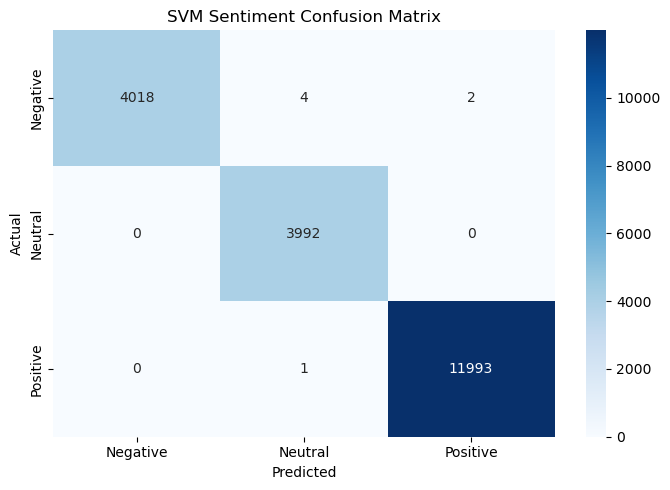

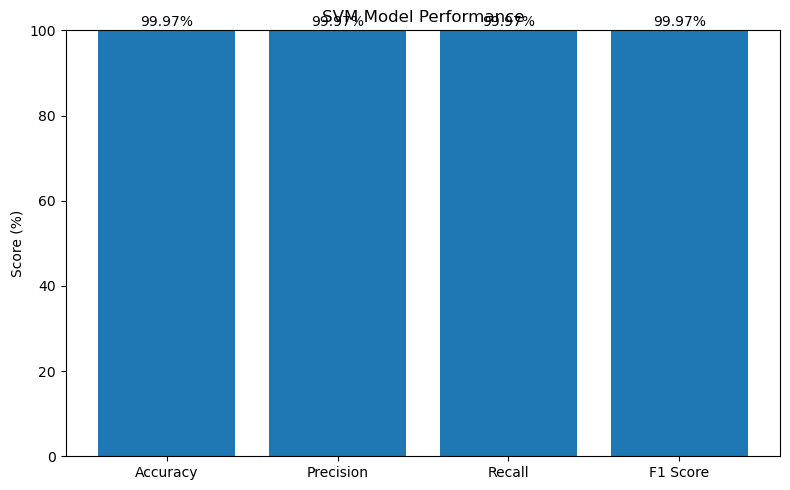

C:\Users\ACER\AppData\Local\Temp\ipykernel_18780\1731680629.py:1870: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(



Models saved successfully.

🚀 LAUNCHING E-COMMERCE SENTIMENT ANALYZER
* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.


In [5]:
# ============================================================
# 🛒 E-COMMERCE PRODUCT REVIEW SENTIMENT ANALYZER
# ============================================================
# NLP + TF-IDF + SVM + Gradio
# Modern Dark Blue / Cyan / Orange UI
# ============================================================

import pandas as pd
import numpy as np
import re
import nltk
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. NLTK
# ============================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


# ============================================================
# 2. LOAD DATASET
# ============================================================

DATASET_PATH = "ecommerce_product_reviews_100k.csv"

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "product_category",
    "product_name",
    "main_aspect",
    "review_text",
    "sentiment"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 4. CLEAN DATA
# ============================================================

df = df.dropna(
    subset=required_columns
)

df = df.drop_duplicates()

for col in [
    "product_category",
    "product_name",
    "main_aspect",
    "review_text"
]:
    df[col] = df[col].astype(str)

df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

sentiment_mapping = {
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral",
    "pos": "Positive",
    "neg": "Negative",
    "neu": "Neutral"
}

df["sentiment"] = df[
    "sentiment"
].map(sentiment_mapping)

df = df.dropna(
    subset=["sentiment"]
)

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())


# ============================================================
# 5. NLP PREPROCESSING
# ============================================================

stop_words = set(
    stopwords.words("english")
)

important_words = {
    "not",
    "no",
    "never",
    "very",
    "without",
    "against",
    "bad",
    "good",
    "worst",
    "terrible",
    "poor",
    "excellent",
    "amazing",
    "great",
    "love",
    "hate",
    "disappointed",
    "awful"
}

stop_words = stop_words - important_words

lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    words = text.split()

    cleaned_words = []

    for word in words:

        if word not in stop_words:

            word = lemmatizer.lemmatize(
                word
            )

            cleaned_words.append(word)

    return " ".join(
        cleaned_words
    )


# ============================================================
# 6. COMBINE TEXT
# ============================================================

df["combined_text"] = (
    df["product_category"]
    + " "
    + df["product_name"]
    + " "
    + df["main_aspect"]
    + " "
    + df["review_text"]
)

df["clean_text"] = df[
    "combined_text"
].apply(clean_text)


# ============================================================
# 7. EXTRA SENTIMENT TRAINING DATA
# ============================================================

extra_data = [

    # Positive
    ("Electronics", "Headphones", "Battery",
     "The battery life is very good", "Positive"),

    ("Electronics", "Speaker", "Sound",
     "The sound quality is excellent", "Positive"),

    ("Electronics", "Phone", "Camera",
     "The camera quality is amazing", "Positive"),

    ("Fashion", "T Shirt", "Quality",
     "The fabric quality is very good", "Positive"),

    ("Electronics", "Laptop", "Performance",
     "The laptop performance is excellent", "Positive"),

    ("Electronics", "Smart Watch", "Features",
     "I love this product", "Positive"),

    ("Beauty", "Face Cream", "Quality",
     "This product is really good", "Positive"),

    ("Home", "Table Lamp", "Design",
     "The design is beautiful", "Positive"),

    ("Fashion", "Running Shoes", "Comfort",
     "These shoes are very comfortable", "Positive"),

    ("Electronics", "Keyboard", "Quality",
     "Excellent quality and great performance", "Positive"),

    # Negative
    ("Electronics", "Headphones", "Battery",
     "The battery is very bad", "Negative"),

    ("Electronics", "Speaker", "Sound",
     "The sound quality is terrible", "Negative"),

    ("Electronics", "Phone", "Camera",
     "The camera quality is very poor", "Negative"),

    ("Fashion", "T Shirt", "Quality",
     "The fabric quality is very bad", "Negative"),

    ("Home Appliances", "Kettle", "Performance",
     "This product is terrible", "Negative"),

    ("Electronics", "Laptop", "Performance",
     "The laptop is very slow and bad", "Negative"),

    ("Electronics", "Smart Watch", "Features",
     "I hate this product", "Negative"),

    ("Beauty", "Face Cream", "Quality",
     "This product is horrible", "Negative"),

    ("Home", "Table Lamp", "Quality",
     "The quality is awful", "Negative"),

    ("Fashion", "Shoes", "Comfort",
     "The shoes are very uncomfortable", "Negative"),

    ("Electronics", "Headphones", "Sound",
     "The sound is not good", "Negative"),

    ("Electronics", "Speaker", "Battery",
     "The battery is not good at all", "Negative"),

    ("Electronics", "Phone", "Display",
     "The display is poor and disappointing", "Negative"),

    ("Fashion", "Jeans", "Fit",
     "The fit is not good", "Negative"),

    ("Home Appliances", "Mixer", "Performance",
     "The performance is very bad", "Negative"),

    ("Electronics", "Keyboard", "Keys",
     "The keys are terrible", "Negative"),

    ("Electronics", "Mouse", "Performance",
     "This is the worst mouse I have used", "Negative"),

    ("Beauty", "Shampoo", "Quality",
     "The product quality is horrible", "Negative"),

    ("Home", "Chair", "Comfort",
     "The chair is uncomfortable and poor", "Negative"),

    ("Fashion", "Jacket", "Material",
     "The material is very poor", "Negative"),

    # Neutral
    ("Electronics", "Headphones", "Battery",
     "The battery is average", "Neutral"),

    ("Electronics", "Speaker", "Sound",
     "The sound quality is okay", "Neutral"),

    ("Electronics", "Phone", "Camera",
     "The camera is average", "Neutral"),

    ("Fashion", "T Shirt", "Quality",
     "The quality is normal", "Neutral"),

    ("Home Appliances", "Kettle", "Performance",
     "The product works okay", "Neutral"),

    ("Electronics", "Laptop", "Performance",
     "The laptop performance is average", "Neutral"),

    ("Electronics", "Smart Watch", "Features",
     "The features are okay", "Neutral"),

    ("Beauty", "Face Cream", "Quality",
     "The result is average", "Neutral"),

    ("Home", "Table Lamp", "Design",
     "The design is simple", "Neutral"),

    ("Fashion", "Shoes", "Comfort",
     "The comfort is average", "Neutral"),

    # Mixed
    ("Electronics", "Earbuds", "Sound",
     "Very good sound but the battery is average",
     "Positive"),

    ("Electronics", "Speaker", "Quality",
     "Good design but very bad sound",
     "Negative"),

    ("Fashion", "Shirt", "Material",
     "The material is excellent",
     "Positive"),

    ("Electronics", "Phone", "Performance",
     "Not good. The phone is very slow",
     "Negative"),

    ("Home", "Chair", "Quality",
     "Nothing special, just an average chair",
     "Neutral"),

    ("Electronics", "Laptop", "Battery",
     "Amazing performance and very good battery",
     "Positive"),

    ("Beauty", "Cream", "Quality",
     "Very bad product. I am disappointed",
     "Negative"),

    ("Fashion", "Shoes", "Quality",
     "The shoes are good but the quality is average",
     "Positive"),

    ("Electronics", "Keyboard", "Quality",
     "Excellent quality and great performance",
     "Positive"),

    ("Electronics", "Mouse", "Performance",
     "Worst product. I do not recommend it",
     "Negative")
]


extra_df = pd.DataFrame(
    extra_data,
    columns=[
        "product_category",
        "product_name",
        "main_aspect",
        "review_text",
        "sentiment"
    ]
)


extra_df["combined_text"] = (
    extra_df["product_category"]
    + " "
    + extra_df["product_name"]
    + " "
    + extra_df["main_aspect"]
    + " "
    + extra_df["review_text"]
)

extra_df["clean_text"] = (
    extra_df["combined_text"]
    .apply(clean_text)
)


# ============================================================
# 8. COMBINE DATA
# ============================================================

training_df = pd.concat(
    [
        df[
            ["clean_text", "sentiment"]
        ],

        extra_df[
            ["clean_text", "sentiment"]
        ]
    ],
    ignore_index=True
)


X = training_df["clean_text"]
y = training_df["sentiment"]


# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 10. TF-IDF
# ============================================================

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)


# ============================================================
# 11. SVM
# ============================================================

print("\nTraining SVM...")

model = LinearSVC(
    C=1.5,
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("SVM TRAINING COMPLETE")


# ============================================================
# 12. EVALUATION
# ============================================================

y_pred = model.predict(
    X_test_tfidf
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

plt.title(
    "SVM Sentiment Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300
)

plt.show()


# ============================================================
# 14. PERFORMANCE GRAPH
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

metric_values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    metric_names,
    metric_values
)

plt.ylim(
    0,
    100
)

plt.ylabel(
    "Score (%)"
)

plt.title(
    "SVM Model Performance"
)

for i, value in enumerate(
    metric_values
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "model_performance.png",
    dpi=300
)

plt.show()


# ============================================================
# 15. SAVE MODEL
# ============================================================

joblib.dump(
    model,
    "ecommerce_svm_sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "ecommerce_tfidf_vectorizer.pkl"
)

print("\nModels saved successfully.")


# ============================================================
# 16. PREDICTION FUNCTION
# ============================================================

def predict_sentiment(
    product_category,
    product_name,
    main_aspect,
    customer_review
):

    product_category = str(
        product_category or ""
    )

    product_name = str(
        product_name or ""
    )

    main_aspect = str(
        main_aspect or ""
    )

    customer_review = str(
        customer_review or ""
    )

    if not customer_review.strip():

        return """
        <div class="result-card">
            <div class="result-icon">⚠️</div>
            <div class="result-title">
                REVIEW REQUIRED
            </div>
            <div class="result-message">
                Please enter a customer review.
            </div>
        </div>
        """


    combined_text = (
        product_category
        + " "
        + product_name
        + " "
        + main_aspect
        + " "
        + customer_review
    )

    cleaned = clean_text(
        combined_text
    )

    vector = tfidf.transform(
        [cleaned]
    )

    prediction = model.predict(
        vector
    )[0]

    scores = model.decision_function(
        vector
    )[0]

    # Relative score
    exp_scores = np.exp(
        scores - np.max(scores)
    )

    probabilities = (
        exp_scores / exp_scores.sum()
    )

    classes = model.classes_

    score_dict = dict(
        zip(
            classes,
            probabilities
        )
    )

    confidence = (
        score_dict[prediction] * 100
    )


    # ========================================================
    # STRONG PHRASE DETECTION
    # ========================================================

    review_lower = (
        customer_review.lower()
    )

    negative_phrases = [
        "very bad",
        "really bad",
        "extremely bad",
        "too bad",
        "terrible",
        "worst",
        "awful",
        "horrible",
        "very poor",
        "really poor",
        "poor quality",
        "not good",
        "not good at all",
        "hate this",
        "hate it",
        "very disappointed",
        "extremely disappointed"
    ]

    positive_phrases = [
        "very good",
        "really good",
        "extremely good",
        "excellent",
        "amazing",
        "awesome",
        "great",
        "love this",
        "love it",
        "very satisfied",
        "high quality"
    ]


    if any(
        phrase in review_lower
        for phrase in negative_phrases
    ):

        prediction = "Negative"

        confidence = max(
            confidence,
            90
        )


    elif any(
        phrase in review_lower
        for phrase in positive_phrases
    ):

        prediction = "Positive"

        confidence = max(
            confidence,
            90
        )


    # ========================================================
    # RESULT DATA
    # ========================================================

    if prediction == "Positive":

        emoji = "😊"

        title = "POSITIVE REVIEW"

        message = (
            "The customer has a positive "
            "opinion about this product."
        )

        accent = "positive"


    elif prediction == "Negative":

        emoji = "😞"

        title = "NEGATIVE REVIEW"

        message = (
            "The customer has a negative "
            "opinion about this product."
        )

        accent = "negative"


    else:

        emoji = "😐"

        title = "NEUTRAL REVIEW"

        message = (
            "The customer has a neutral "
            "or mixed opinion about this product."
        )

        accent = "neutral"


    # ========================================================
    # MODERN RESULT HTML
    # ========================================================

    return f"""

    <div class="result-card {accent}">

        <div class="result-top-line"></div>

        <div class="result-icon">
            {emoji}
        </div>

        <div class="result-title">
            {title}
        </div>

        <div class="result-message">
            {message}
        </div>

        <div class="result-separator"></div>

        <div class="stats-row">

            <div class="stat-card">

                <div class="stat-icon">
                    ◉
                </div>

                <div class="stat-label">
                    SENTIMENT
                </div>

                <div class="stat-value">
                    {prediction}
                </div>

            </div>


            <div class="stat-card">

                <div class="stat-icon">
                    ◈
                </div>

                <div class="stat-label">
                    CONFIDENCE
                </div>

                <div class="stat-value">
                    {confidence:.2f}%
                </div>

            </div>

        </div>


        <div class="confidence-title">
            MODEL CONFIDENCE
        </div>

        <div class="confidence-bar">

            <div
                class="confidence-fill"
                style="width:{min(confidence, 100):.2f}%"
            ></div>

        </div>

        <div class="confidence-number">
            {confidence:.2f}% confidence
        </div>

    </div>

    """


# ============================================================
# 17. MODERN UI CSS
# ============================================================

custom_css = """

/* =========================================================
   MAIN BACKGROUND
   ========================================================= */

body {

    background:
        radial-gradient(
            circle at 10% 10%,
            #102b45 0%,
            transparent 30%
        ),
        radial-gradient(
            circle at 90% 20%,
            #17263a 0%,
            transparent 28%
        ),
        #03070c !important;

    color: white !important;
}


.gradio-container {

    max-width: 1250px !important;

    margin: auto !important;

    background:
        linear-gradient(
            145deg,
            #071019,
            #020509
        ) !important;

    color: white !important;

    padding-bottom: 35px !important;
}


/* =========================================================
   HERO
   ========================================================= */

.hero {

    position: relative;

    overflow: hidden;

    text-align: center;

    padding: 48px 25px;

    margin-bottom: 28px;

    border-radius: 26px;

    background:
        linear-gradient(
            135deg,
            #071522,
            #0a1018 55%,
            #10151c
        );

    border: 1px solid #173b55;

    box-shadow:
        0 0 35px
        rgba(0, 180, 255, 0.10);
}


.hero::before {

    content: "";

    position: absolute;

    width: 350px;

    height: 350px;

    top: -220px;

    left: -80px;

    border-radius: 50%;

    background:
        radial-gradient(
            circle,
            rgba(0, 200, 255, 0.20),
            transparent 70%
        );
}


.hero::after {

    content: "";

    position: absolute;

    width: 300px;

    height: 300px;

    bottom: -200px;

    right: -80px;

    border-radius: 50%;

    background:
        radial-gradient(
            circle,
            rgba(255, 145, 0, 0.16),
            transparent 70%
        );
}


.hero-badge {

    position: relative;

    display: inline-block;

    padding: 7px 18px;

    border-radius: 30px;

    background: #071c2b;

    border: 1px solid #14506f;

    color: #4ddcff;

    font-size: 12px;

    font-weight: 800;

    letter-spacing: 2px;

    margin-bottom: 14px;
}


.hero h1 {

    position: relative;

    font-size: 40px;

    font-weight: 900;

    margin: 5px 0 12px;

    color: #ffffff !important;

    text-shadow:
        0 0 18px
        rgba(0, 200, 255, 0.25);
}


.hero h1 span {

    color: #ffad32;
}


.hero p {

    position: relative;

    color: #8da1b5 !important;

    font-size: 15px;

    margin: 6px 0;
}


/* =========================================================
   SECTION TITLE
   ========================================================= */

.section-title {

    font-size: 21px;

    font-weight: 850;

    color: #ffffff !important;

    margin: 20px 0 5px;
}


.section-title::first-letter {

    color: #20d9ff;
}


.section-subtitle {

    color: #718397 !important;

    font-size: 13px;

    margin-bottom: 18px;
}


/* =========================================================
   INPUT PANEL
   ========================================================= */

.input-card {

    padding: 25px !important;

    border-radius: 22px !important;

    background:
        linear-gradient(
            145deg,
            #0b151f,
            #070d14
        ) !important;

    border: 1px solid #16354b !important;

    box-shadow:
        inset 0 1px 0
        rgba(255,255,255,0.03),
        0 15px 40px
        rgba(0,0,0,0.45);
}


/* =========================================================
   INPUT BOXES
   ========================================================= */

textarea,
input {

    background: #060b11 !important;

    color: #e8f5ff !important;

    border: 1px solid #1b4058 !important;

    border-radius: 12px !important;

    transition: 0.25s ease !important;
}


textarea:hover,
input:hover {

    border-color: #236783 !important;
}


textarea:focus,
input:focus {

    border-color: #20cfff !important;

    box-shadow:
        0 0 0 1px #20cfff,
        0 0 18px
        rgba(32,207,255,0.12) !important;
}


label {

    color: #9bb0c3 !important;

    font-size: 13px !important;

    font-weight: 700 !important;
}


/* =========================================================
   PREDICT BUTTON
   ========================================================= */

.predict-btn {

    min-height: 57px !important;

    margin-top: 10px !important;

    border-radius: 13px !important;

    border: 1px solid #ffbd4a !important;

    background:
        linear-gradient(
            135deg,
            #ffb21c,
            #ff7a00
        ) !important;

    color: #080b0f !important;

    font-size: 17px !important;

    font-weight: 900 !important;

    box-shadow:
        0 0 20px
        rgba(255, 145, 0, 0.15);

    transition: 0.25s ease !important;
}


.predict-btn:hover {

    transform: translateY(-2px);

    box-shadow:
        0 0 30px
        rgba(255, 145, 0, 0.30);
}


/* =========================================================
   RESULT CARD
   ========================================================= */

.result-card {

    position: relative;

    overflow: hidden;

    padding: 32px 28px;

    margin-top: 8px;

    text-align: center;

    border-radius: 23px;

    background:
        linear-gradient(
            145deg,
            #0a151f,
            #05090e
        );

    border: 1px solid #17415b;

    box-shadow:
        0 0 40px
        rgba(0, 190, 255, 0.08);
}


.result-top-line {

    position: absolute;

    top: 0;

    left: 10%;

    width: 80%;

    height: 2px;

    background:
        linear-gradient(
            90deg,
            transparent,
            #20d9ff,
            #ff9d20,
            transparent
        );

    box-shadow:
        0 0 15px
        rgba(32,217,255,0.5);
}


.result-icon {

    font-size: 62px;

    margin: 5px 0 5px;

    filter:
        drop-shadow(
            0 0 12px
            rgba(0,200,255,0.2)
        );
}


.result-title {

    font-size: 28px;

    font-weight: 900;

    color: #ffffff;
}


.result-message {

    color: #8194a7;

    margin-top: 9px;

    font-size: 14px;
}


.result-separator {

    height: 1px;

    background: #183041;

    margin: 24px 0;
}


/* =========================================================
   RESULT STATS
   ========================================================= */

.stats-row {

    display: grid;

    grid-template-columns:
        1fr 1fr;

    gap: 14px;
}


.stat-card {

    padding: 18px;

    border-radius: 15px;

    background: #071019;

    border: 1px solid #173449;

    text-align: left;
}


.stat-icon {

    color: #22d9ff;

    font-size: 18px;

    margin-bottom: 7px;
}


.stat-label {

    color: #607487;

    font-size: 10px;

    font-weight: 800;

    letter-spacing: 1.5px;
}


.stat-value {

    margin-top: 5px;

    color: #ffffff;

    font-size: 20px;

    font-weight: 900;
}


/* =========================================================
   CONFIDENCE
   ========================================================= */

.confidence-title {

    margin-top: 22px;

    text-align: left;

    color: #70869a;

    font-size: 10px;

    font-weight: 800;

    letter-spacing: 1.5px;
}


.confidence-bar {

    width: 100%;

    height: 8px;

    margin-top: 8px;

    border-radius: 20px;

    overflow: hidden;

    background: #13212c;
}


.confidence-fill {

    height: 100%;

    border-radius: 20px;

    background:
        linear-gradient(
            90deg,
            #13c9ff,
            #2de0ff,
            #ffae32
        );

    box-shadow:
        0 0 12px
        rgba(32,217,255,0.4);
}


.confidence-number {

    margin-top: 7px;

    text-align: right;

    color: #5f768a;

    font-size: 11px;
}


/* =========================================================
   EXAMPLES
   ========================================================= */

.examples-card {

    padding: 20px;

    margin-top: 25px;

    border-radius: 20px;

    background:
        linear-gradient(
            145deg,
            #09131d,
            #050a10
        );

    border: 1px solid #153449;
}


/* =========================================================
   GRADIO EXAMPLES
   ========================================================= */

button {

    border-radius: 10px !important;
}


.gr-button {

    background: #0b1722 !important;

    color: #9ddfff !important;

    border: 1px solid #17445e !important;
}


.gr-button:hover {

    background: #102333 !important;

    border-color: #20cfff !important;
}


/* =========================================================
   DROPDOWN / GENERAL
   ========================================================= */

.gr-dropdown,
.gr-box {

    background: #071019 !important;

    border-color: #173449 !important;
}


.markdown-text,
.prose {

    color: #b5c5d3 !important;
}


/* =========================================================
   FOOTER
   ========================================================= */

.footer {

    margin-top: 35px;

    padding: 25px;

    text-align: center;

    color: #506477;

    font-size: 12px;

    border-top: 1px solid #112533;
}


.footer strong {

    color: #8ca4b8;
}


/* =========================================================
   MOBILE
   ========================================================= */

@media (max-width: 700px) {

    .hero {

        padding: 38px 17px;

        border-radius: 20px;
    }

    .hero h1 {

        font-size: 29px;
    }

    .hero p {

        font-size: 13px;
    }

    .input-card {

        padding: 18px !important;
    }

    .stats-row {

        grid-template-columns: 1fr;
    }

    .result-title {

        font-size: 23px;
    }

}
"""


# ============================================================
# 18. 50 EXAMPLES
# ============================================================

examples = [

    # Positive
    ["Electronics", "Wireless Headphones",
     "Battery", "The battery life is excellent and amazing."],

    ["Electronics", "Bluetooth Speaker",
     "Sound", "The sound quality is very good."],

    ["Electronics", "Mobile Phone",
     "Camera", "The camera quality is excellent."],

    ["Fashion", "Cotton T-Shirt",
     "Quality", "The fabric quality is amazing."],

    ["Home Appliances", "Electric Kettle",
     "Performance", "This product works very well."],

    ["Electronics", "Laptop",
     "Performance", "The laptop is fast and excellent."],

    ["Electronics", "Smart Watch",
     "Features", "I love this product."],

    ["Beauty", "Face Cream",
     "Skin Feel", "The product is really good."],

    ["Home", "Table Lamp",
     "Design", "The design is beautiful and great."],

    ["Fashion", "Running Shoes",
     "Comfort", "These shoes are very comfortable."],

    # Negative
    ["Electronics", "Wireless Headphones",
     "Battery", "The battery is very bad."],

    ["Electronics", "Bluetooth Speaker",
     "Sound", "The sound quality is terrible."],

    ["Electronics", "Mobile Phone",
     "Camera", "The camera quality is very poor."],

    ["Fashion", "Cotton T-Shirt",
     "Quality", "The fabric quality is very bad."],

    ["Home Appliances", "Electric Kettle",
     "Performance", "This product is terrible."],

    ["Electronics", "Laptop",
     "Performance", "The laptop is extremely slow and bad."],

    ["Electronics", "Smart Watch",
     "Features", "I hate this product."],

    ["Beauty", "Face Cream",
     "Skin Feel", "This product is horrible."],

    ["Home", "Table Lamp",
     "Quality", "The quality is awful."],

    ["Fashion", "Running Shoes",
     "Comfort", "The shoes are very uncomfortable."],

    ["Electronics", "Headphones",
     "Sound", "The sound is not good."],

    ["Electronics", "Speaker",
     "Battery", "The battery is not good at all."],

    ["Electronics", "Mobile Phone",
     "Display", "The display is poor and disappointing."],

    ["Fashion", "Jeans",
     "Fit", "The fit is not good."],

    ["Home Appliances", "Mixer",
     "Performance", "The performance is very bad."],

    ["Electronics", "Keyboard",
     "Keys", "The keys are terrible."],

    ["Electronics", "Mouse",
     "Performance", "This is the worst mouse I have used."],

    ["Beauty", "Shampoo",
     "Quality", "The product quality is horrible."],

    ["Home", "Chair",
     "Comfort", "The chair is uncomfortable and poor."],

    ["Fashion", "Jacket",
     "Material", "The material is very poor."],

    # Neutral
    ["Electronics", "Headphones",
     "Battery", "The battery is average."],

    ["Electronics", "Speaker",
     "Sound", "The sound quality is okay."],

    ["Electronics", "Mobile Phone",
     "Camera", "The camera is average."],

    ["Fashion", "T-Shirt",
     "Quality", "The quality is normal."],

    ["Home Appliances", "Kettle",
     "Performance", "The product works okay."],

    ["Electronics", "Laptop",
     "Performance", "The laptop is average."],

    ["Electronics", "Smart Watch",
     "Features", "The features are okay."],

    ["Beauty", "Face Cream",
     "Skin Feel", "The result is average."],

    ["Home", "Table Lamp",
     "Design", "The design is simple."],

    ["Fashion", "Shoes",
     "Comfort", "The comfort is average."],

    # Mixed
    ["Electronics", "Earbuds",
     "Sound", "Very good sound but the battery is average."],

    ["Electronics", "Speaker",
     "Quality", "Good design but very bad sound."],

    ["Fashion", "Shirt",
     "Material", "The material is excellent."],

    ["Electronics", "Phone",
     "Performance", "Not good. The phone is very slow."],

    ["Home", "Chair",
     "Quality", "Nothing special, just an average chair."],

    ["Electronics", "Laptop",
     "Battery", "Amazing performance and very good battery."],

    ["Beauty", "Cream",
     "Quality", "Very bad product. I am disappointed."],

    ["Fashion", "Shoes",
     "Quality", "The shoes are good but the quality is average."],

    ["Electronics", "Keyboard",
     "Quality", "Excellent quality and great performance."],

    ["Electronics", "Mouse",
     "Performance", "Worst product. I do not recommend it."]
]


# ============================================================
# 19. GRADIO APP
# ============================================================

with gr.Blocks(
    css=custom_css,
    title="E-Commerce Product Review Analyzer"
) as demo:


    # ========================================================
    # HERO
    # ========================================================

    gr.HTML(
        """
        <div class="hero">

            <div class="hero-badge">
                ✦ NLP &nbsp; • &nbsp; TF-IDF &nbsp; • &nbsp; SVM
            </div>

            <h1>
                🛒 E-Commerce Product
                <span>Review Analyzer</span>
            </h1>

            <p>
                Intelligent customer review sentiment analysis
            </p>

            <p>
                Positive • Negative • Neutral
            </p>

        </div>
        """
    )


    # ========================================================
    # INPUT TITLE
    # ========================================================

    gr.HTML(
        """
        <div class="section-title">
            ✦ Review Analysis
        </div>

        <div class="section-subtitle">
            Enter product information and customer feedback
            to analyze sentiment.
        </div>
        """
    )


    # ========================================================
    # INPUT CARD
    # ========================================================

    with gr.Group(
        elem_classes="input-card"
    ):

        with gr.Row():

            product_category = gr.Textbox(
                label="Product Category",
                placeholder="Electronics",
                value="Electronics"
            )

            product_name = gr.Textbox(
                label="Product Name",
                placeholder="Wireless Headphones",
                value="Wireless Headphones"
            )


        with gr.Row():

            main_aspect = gr.Textbox(
                label="Main Aspect",
                placeholder="Battery",
                value="Battery"
            )


        customer_review = gr.Textbox(
            label="Customer Review",
            placeholder=(
                "Write the customer's review here..."
            ),
            lines=5
        )


        predict_button = gr.Button(
            "⚡ ANALYZE REVIEW",
            elem_classes="predict-btn"
        )


    # ========================================================
    # RESULT TITLE
    # ========================================================

    gr.HTML(
        """
        <div class="section-title">
            ◈ Analysis Result
        </div>

        <div class="section-subtitle">
            AI-powered sentiment prediction
        </div>
        """
    )


    # ========================================================
    # RESULT
    # ========================================================

    result = gr.HTML(
        """
        <div class="result-card">

            <div class="result-icon">
                🤖
            </div>

            <div class="result-title">
                READY
            </div>

            <div class="result-message">
                Enter a review to start the analysis.
            </div>

        </div>
        """
    )


    # ========================================================
    # BUTTON ACTION
    # ========================================================

    predict_button.click(
        fn=predict_sentiment,

        inputs=[
            product_category,
            product_name,
            main_aspect,
            customer_review
        ],

        outputs=result
    )


    # ========================================================
    # EXAMPLES
    # ========================================================

    gr.HTML(
        """
        <div class="examples-card">

            <div class="section-title">
                🧪 Test Examples
            </div>

            <div class="section-subtitle">
                Try any of the 50 sample customer reviews.
            </div>

        </div>
        """
    )


    gr.Examples(
        examples=examples,

        inputs=[
            product_category,
            product_name,
            main_aspect,
            customer_review
        ],

        outputs=result,

        fn=predict_sentiment,

        cache_examples=False
    )


    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML(
        """
        <div class="footer">

            <strong>
                E-Commerce Product Review Sentiment Analyzer
            </strong>

            <br><br>

            Natural Language Processing
            &nbsp; • &nbsp;
            TF-IDF
            &nbsp; • &nbsp;
            Support Vector Machine

            <br><br>

            Data Science / B1
            &nbsp; • &nbsp;
            Trycod

            <br><br>

            Developed by
            <strong>Muhammed Dhilshad</strong>

        </div>
        """
    )


# ============================================================
# 20. LAUNCH
# ============================================================

print("\n" + "=" * 60)
print("🚀 LAUNCHING E-COMMERCE SENTIMENT ANALYZER")
print("=" * 60)

demo.launch()